# Manual QC and optotag

In [1]:
import os
import numpy as np
import mat73
import pandas as pd
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import pyNeuroDAP as ndap

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

In [2]:
session_name = '20251207-SL412-Reward1_g0'

# Read data
exp_name = '202512-Ephys-LHb'
session_path = rf'/Users/shunli/Projects/pyNeuroDAP/Data/{session_name}'
spike_path = os.path.join(session_path, rf'AIND_{session_name}')
nwb_path = os.path.join(session_path, 'nwb','ecephys_session_block0_recording1.nwb')
save_folder = os.path.join(session_path, 'results')

print('Analyzing session: ', session_name)
print('Session path: ', session_path)
print('Spike path: ', spike_path)
print('Save folder: ', save_folder)

Analyzing session:  20251207-SL412-Reward1_g0
Session path:  /Users/shunli/Projects/pyNeuroDAP/Data/20251207-SL412-Reward1_g0
Spike path:  /Users/shunli/Projects/pyNeuroDAP/Data/20251207-SL412-Reward1_g0/AIND_20251207-SL412-Reward1_g0
Save folder:  /Users/shunli/Projects/pyNeuroDAP/Data/20251207-SL412-Reward1_g0/results


In [3]:
# # (Optional) copy files from server to local
# microscope_path = rf'/Volumes/MICROSCOPE/Shun/Project valence/Recordings/{exp_name}/'
# os.makedirs(session_path, exist_ok=True)

# # Copy AIND_* folder from server to local
# aind_path = os.path.join(microscope_path, f'spike_sorted/{session_name}_output/AIND_{session_name}')
# !cp -r "$aind_path" "$session_path"
# print('Copied AIND_* folder from server to local')

# # Copy nwb folder from server to local
# nwb_path = os.path.join(microscope_path, f'nwb')
# !cp -r "$nwb_path" "$session_path"
# print('Copied nwb folder from server to local')

# # Copy essentiall mat files from server to local
# microscope_session_path = os.path.join(microscope_path, session_name)
# microscope_sync_mat_path = os.path.join(microscope_session_path, f'sync_{session_name}.mat')
# microscope_data_mat_path = os.path.join(microscope_session_path, f'data_{session_name}.mat')
# microscope_analysis_mat_path = os.path.join(microscope_session_path, f'analysis_{session_name}.mat')
# microscope_behavior_mat_path = os.path.join(microscope_session_path, f'behavior_{session_name}.mat')
# microscope_timeseries_mat_path = os.path.join(microscope_session_path, f'timeseries_{session_name}.mat')
# !cp "$microscope_sync_mat_path" "$session_path"
# print(f'Copied sync_{session_name}.mat from server to local')
# !cp "$microscope_data_mat_path" "$session_path"
# print(f'Copied data_{session_name}.mat from server to local')
# !cp "$microscope_analysis_mat_path" "$session_path"
# print(f'Copied analysis_{session_name}.mat from server to local')
# !cp "$microscope_behavior_mat_path" "$session_path"
# print(f'Copied behavior_{session_name}.mat from server to local')
# !cp "$microscope_timeseries_mat_path" "$session_path"
# print(f'Copied timeseries_{session_name}.mat from server to local')

In [4]:
# Create local results folder
os.makedirs(save_folder, exist_ok=True)

# Set sampling frequencies
apFs = 30000
behaviorFs = 10000
photometryFs = 50
cameraFs = 50

# Read the tsv files 
print(spike_path)
tvs_files = [f for f in os.listdir(spike_path) if f.endswith('.tsv')]
print(tvs_files)
# Read the npy files
npy_files = [f for f in os.listdir(spike_path) if f.endswith('.npy')]
print(npy_files)

# Load cluster group and cluster info
cluster_group = pd.read_csv(os.path.join(spike_path, 'cluster_group.tsv'), sep='\t')
cluster_info = pd.read_csv(os.path.join(spike_path, 'cluster_info.tsv'), sep='\t')
cluster_info = cluster_info.merge(cluster_group, on='global_unit_ids')

# Read in sorting_curation.json if exists
import json
if os.path.exists(os.path.join(spike_path, 'sorting-curation.json')):
    sorting_curation = json.load(open(os.path.join(spike_path, 'sorting-curation.json')))
    print(sorting_curation)
else:
    sorting_curation = None
    print('No sorting curation file found, default to None')

# Make putative manualquality column
cluster_info['manual_quality'] = cluster_info['default_qc']
if sorting_curation is not None and 'labelsByUnit' in sorting_curation:
    label_map = {int(k): v for k, v in sorting_curation['labelsByUnit'].items()}
    cluster_info['manual_quality'] = cluster_info['unit_ids'].map(label_map).where(
        cluster_info['unit_ids'].map(label_map).notna(),
        cluster_info['default_qc']
    )
    # Convert list labels to boolean: True if not 'noise', False if 'noise'
    cluster_info['manual_quality'] = cluster_info['manual_quality'].apply(
        lambda x: x if isinstance(x, bool) else ('noise' not in x if isinstance(x, list) else x)
    )

# Display the unit_id, default_qc, and manual_quality columns
cluster_info[["unit_ids","global_unit_ids","default_qc","manual_quality"]].head()


/Users/shunli/Projects/pyNeuroDAP/Data/20251207-SL412-Reward1_g0/AIND_20251207-SL412-Reward1_g0
['cluster_info.tsv', 'template_metrics.tsv', 'cluster_group.tsv']
['spike_times.npy', 'spike_clusters.npy', 'best_channel_templates.npy']
{'labelsByUnit': {'0': ['pMUA'], '10': ['pMUA'], '104': ['noise'], '11': ['pMUA'], '115': ['noise'], '126': ['noise'], '128': ['pMUA'], '146': ['MUA'], '162': ['pMUA'], '199': ['pMUA'], '250': ['pSUA'], '253': ['noise'], '265': ['noise'], '274': ['noise'], '282': ['pMUA'], '285': ['noise'], '81': ['pMUA']}}


,unit_ids,global_unit_ids,default_qc,manual_quality
0,0,1,False,True
1,1,2,True,True
2,2,3,True,True
3,3,4,True,True
4,4,5,True,True


## Manual QC

In [5]:
# Manual QC based on quality metrics

# ISI violation ratio < 0.5
# presence ratio > 0.8
# amplitude cutoff < 0.1
ISI_violation_ratio_cutoff = 0.5
presence_ratio_cutoff = 0.8
amplitude_cutoff = 0.1

# Only set quality to False if it was originally True AND fails QC criteria
cluster_info['quality'] = cluster_info['manual_quality']
fails_qc = (cluster_info['isi_violations_ratio'] > ISI_violation_ratio_cutoff) | \
           (cluster_info['presence_ratio'] < presence_ratio_cutoff) | \
           (cluster_info['amplitude_cutoff'] > amplitude_cutoff)
cluster_info.loc[(cluster_info['manual_quality'] == True) & fails_qc, 'quality'] = False

In [6]:
# Create a boolean mask for bad channels (0-8, 223-239, 288-335) and less bad (128-143)
bad_channels_mask = (
    ((cluster_info['peak_channel'] >= 0) & (cluster_info['peak_channel'] <= 8)) |
    ((cluster_info['peak_channel'] >= 223) & (cluster_info['peak_channel'] <= 239)) |
    ((cluster_info['peak_channel'] >= 288) & (cluster_info['peak_channel'] <= 335))
)
less_bad_channels_mask = (
    (cluster_info['peak_channel'] >= 128) & (cluster_info['peak_channel'] <= 143)
)
# Remove units in bad channels
cluster_info.loc[bad_channels_mask, 'quality'] = False

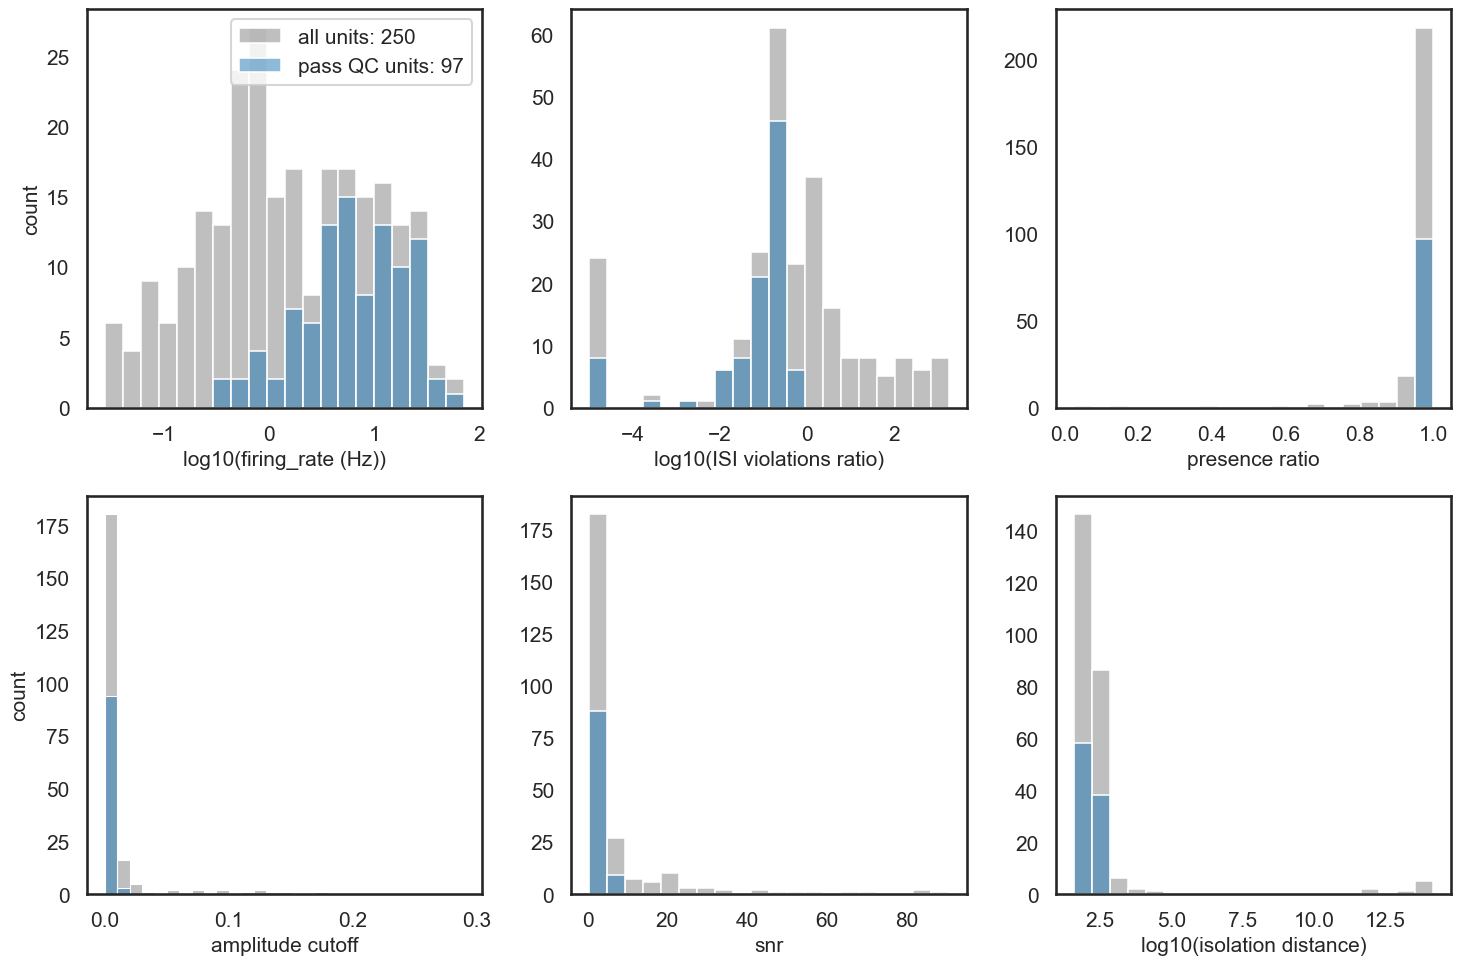

In [7]:
# in this histogram we have all units in the gray and that ovelay the units that pass the quality metrics in the green
num_of_bins = 20
font_size = 15
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
# let do the firing rate histogram in the log scale
fr_log = np.log10(cluster_info['firing_rate'])
bins_fr = np.histogram_bin_edges(fr_log, bins=num_of_bins)
sns.histplot(fr_log, bins=bins_fr, color='gray', ax=ax[0, 0], edgecolor=None, alpha=0.5)
sns.histplot(fr_log[cluster_info['quality']], bins=bins_fr, ax=ax[0, 0], edgecolor=None, alpha=0.5)
ax[0, 0].set_xlabel('log10(firing_rate (Hz))', fontsize=font_size)

# let do the isi_violations_ratio histogram
ISI_vio_log = np.log10(cluster_info['isi_violations_ratio']+10**-5)
bins_ISI_vio = np.histogram_bin_edges(ISI_vio_log, bins=num_of_bins)
sns.histplot(ISI_vio_log, bins=bins_ISI_vio, color='gray', ax=ax[0, 1], edgecolor=None, alpha=0.5)
sns.histplot(ISI_vio_log[cluster_info['quality']], bins=bins_ISI_vio, ax=ax[0, 1], edgecolor=None, alpha=0.5)
ax[0, 1].set_xlabel('log10(ISI violations ratio)', fontsize=font_size)

# let do the presence_ratio histogram
present_ratio = cluster_info['presence_ratio']
bins_present_ratio = np.histogram_bin_edges(present_ratio, bins=num_of_bins)
sns.histplot(present_ratio, bins=bins_present_ratio, color='gray', ax=ax[0, 2], edgecolor=None, alpha=0.5)
sns.histplot(present_ratio[cluster_info['quality']], bins=bins_present_ratio, ax=ax[0, 2], edgecolor=None, alpha=0.5)
ax[0, 2].set_xlabel('presence ratio', fontsize=font_size)

# let do the amplitude_cutoff histogram
amplitude_cutoff = cluster_info['amplitude_cutoff']
bins_amplitude_cutoff = np.arange(0, .3, .01) 
sns.histplot(amplitude_cutoff, bins=bins_amplitude_cutoff, color='gray', ax=ax[1, 0], edgecolor=None, alpha=0.5)
sns.histplot(amplitude_cutoff[cluster_info['quality']], bins=bins_amplitude_cutoff, ax=ax[1, 0], edgecolor=None, alpha=0.5)
ax[1, 0].set_xlabel('amplitude cutoff', fontsize=font_size)

# let do the snr histogram
snr = cluster_info['snr']
bins_snr = np.histogram_bin_edges(snr, bins=num_of_bins)
sns.histplot(snr, bins=bins_snr, color='gray', ax=ax[1, 1], edgecolor=None, alpha=0.5)
sns.histplot(snr[cluster_info['quality']], bins=bins_snr, ax=ax[1, 1], edgecolor=None, alpha=0.5)
ax[1, 1].set_xlabel('snr', fontsize=font_size)

# let do the isolation_distance histogram
isolation_distance = np.log10(cluster_info['isolation_distance']+10**-5)
# let remove the nan values from the isolation_distance
isolation_distance = isolation_distance[~np.isnan(isolation_distance)]
bins_isolation_distance = np.histogram_bin_edges(isolation_distance, bins=num_of_bins)
sns.histplot(isolation_distance, bins=bins_isolation_distance, color='gray', ax=ax[1, 2], edgecolor=None, alpha=0.5)
sns.histplot(isolation_distance[cluster_info['quality']], bins=bins_isolation_distance, ax=ax[1, 2], edgecolor=None, alpha=0.5)
ax[1, 2].set_xlabel('log10(isolation distance)', fontsize=font_size)
# let add the legend to the plot
ax[0, 0].legend([f'all units: {len(fr_log)}', f'pass QC units: {len(fr_log[cluster_info["quality"]])}'], fontsize=font_size)

# let set the font size of the x and y labels and the ticks to the 15
for i in range(2):
    for j in range(3):
        ax[i, j].tick_params(axis='both', which='major', labelsize=15)
        # remmove the y label all the subplots
        if j != 0:
            ax[i, j].set_ylabel('')
        else:
            ax[i, j].set_ylabel('count', fontsize=font_size)
plt.tight_layout()
plt.show()

# let save the figure
fig.savefig(os.path.join(save_folder, 'quality_metrics.png'), dpi=300)
fig.savefig(os.path.join(save_folder, 'quality_metrics.pdf'), dpi=300)

In [8]:
# Save the cluster_info_enhanced to the data folder as tsv file
cluster_info_enhanced = cluster_info
cluster_info_enhanced.to_csv(os.path.join(spike_path, 'cluster_info_enhanced.tsv'), sep='\t', index=False)

# Print number of the neurons that pass the quality metrics
print(cluster_info['manual_quality'].value_counts())
print(cluster_info['quality'].value_counts())
cluster_info_enhanced.head()

manual_quality
True     129
False    121
Name: count, dtype: int64
quality
False    153
True      97
Name: count, dtype: int64


,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,d_prime,drift_mad,drift_ptp,drift_std,firing_range,firing_rate,...,velocity_below,peak_channel,segment_name,n_samples,trough_to_peak_ms,global_unit_ids,labels,default_qc,manual_quality,quality
0,0.010777,0.301269,1.125538,-63.574220,2.997546,NaN,NaN,NaN,1.60,0.651072,...,NaN,18,block0_imec0.ap_recording1,210,0.200000,1,mua,False,True,False
1,0.000429,0.357062,0.997042,-54.492188,3.014356,1.516902,6.716370,0.924027,2.80,2.422723,...,NaN,20,block0_imec0.ap_recording1,210,0.700000,2,mua,True,True,True
2,0.000222,0.312364,0.111799,-57.519530,2.264735,0.343113,2.189102,0.515268,6.60,5.599048,...,NaN,67,block0_imec0.ap_recording1,210,0.700000,3,mua,True,True,True
3,0.000220,0.267902,0.107125,-72.656250,4.226645,1.353287,5.077652,1.433104,13.33,14.570513,...,NaN,66,block0_imec0.ap_recording1,210,0.633333,4,sua,True,True,True
4,0.002668,0.207780,0.095672,-118.066410,3.497605,2.166488,6.505859,2.141684,17.33,18.653811,...,NaN,210,block0_imec0.ap_recording1,210,0.600000,5,sua,True,True,True


## Optotag

### Load spike data

In [9]:
# Setup Fs
apFs = 30000
behaviorFs = 10000
cameraFs = 50

# Load spike data
spike_times = np.load(os.path.join(spike_path, 'spike_times.npy'), allow_pickle=True).flatten()
spike_clusters = np.load(os.path.join(spike_path, 'spike_clusters.npy'), allow_pickle=True).flatten()
segment_index = np.zeros_like(spike_times)  # Always 0
spikes = np.stack([spike_times, spike_clusters, segment_index], axis=1)
print(f'Converted spikes shape: {spikes.shape}')
print(f'First 5 spikes:\n{spikes[:5]}')

# Extract good units
cluster_info_enhanced = pd.read_csv(os.path.join(spike_path, 'cluster_info_enhanced.tsv'), sep='\t')
good_units = cluster_info_enhanced[cluster_info_enhanced['quality']]['global_unit_ids'].values
good_unit_ids = cluster_info_enhanced[cluster_info_enhanced['quality']]['unit_ids'].values
print(f'Number of good units: {len(good_units)}')

cluster_info_enhanced[["unit_ids","global_unit_ids","default_qc","manual_quality","quality","peak_channel"]].head()

Converted spikes shape: (3371370, 3)
First 5 spikes:
[[  0 221   0]
 [  1  96   0]
 [  2 246   0]
 [  2 243   0]
 [  3  14   0]]
Number of good units: 97


,unit_ids,global_unit_ids,default_qc,manual_quality,quality,peak_channel
0,0,1,False,True,False,18
1,1,2,True,True,True,20
2,2,3,True,True,True,67
3,3,4,True,True,True,66
4,4,5,True,True,True,210


### Load behavior & photometry data

In [10]:
# Load sync_*.mat
sync_times = ndap.load_mat(os.path.join(session_path, rf'sync_{session_name}.mat'))
params = ndap.convert_params_from_mat(sync_times)

# Load behavior data
data_mat = ndap.load_mat(os.path.join(session_path, rf'data_{session_name}.mat'))
water = data_mat['rightSolenoid'].flatten() if 'rightSolenoid' in data_mat else None
lick = data_mat['rightLick'].flatten() if 'rightLick' in data_mat else None
tone = data_mat['rightTone'].flatten() if 'rightTone' in data_mat else None
blueLaser = data_mat['blueLaser'].flatten() if 'blueLaser' in data_mat else None
redLaser = data_mat['redLaser'].flatten() if 'redLaser' in data_mat else None
airpuff = data_mat['airpuff'].flatten() if 'airpuff' in data_mat else None
# Extract onset times for continuous events (water, tone, lick) - all rising edges
water_onsets = ndap.get_onset_times(water, edge='rising', fs=behaviorFs, min_separation=0.5)
tone_onsets = ndap.get_onset_times(tone, edge='rising', fs=behaviorFs, min_separation=0.5)
lick_onsets = ndap.get_onset_times(lick, edge='rising', fs=behaviorFs, min_separation=0.5)
airpuff_onsets = ndap.get_onset_times(airpuff, edge='falling', fs=behaviorFs, min_separation=0.5)
# Extract onset times for laser events (filtered by >=500ms separation)
blueLaser_onsets = ndap.get_onset_times(blueLaser, fs=behaviorFs, min_separation=0.5, edge='falling')
redLaser_onsets = ndap.get_onset_times(redLaser, fs=behaviorFs, min_separation=0.5, edge='falling')

# Extract rewarded lick (i.e. first lick after water delivery)
if water_onsets.size == 0 or lick_onsets.size == 0:
    print('No water or lick onsets found')
    water_lick_onsets = np.array([])
else:
    # searchsorted assumes right_lick_on is sorted ascending
    if np.any(np.diff(lick_onsets) < 0):
        lick_onsets_sorted = np.sort(lick_onsets)
    else:
        lick_onsets_sorted = lick_onsets
    pos = np.searchsorted(lick_onsets_sorted, water_onsets, side="left")
    valid = pos < lick_onsets_sorted.size
    water_lick_onsets = lick_onsets_sorted[pos[valid]]


# Load photometry data
timeseries_mat = ndap.load_mat(os.path.join(session_path, rf'timeseries_{session_name}.mat'))
# Extract DA photometry
DA = timeseries_mat['timeSeries']['data'][timeseries_mat['timeSeries']['name'].index('dLight')]
photometryFs = timeseries_mat['timeSeries']['finalFs'][timeseries_mat['timeSeries']['name'].index('dLight')].item()


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: table, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)


In [11]:
# Show photometry trace
# plt.plot(DA[:int(50*photometryFs)])
# plt.show()

### Plot PSTH near blue opto

Aligning spikes to onsets...
Finished: aligned 200 events
Shape: (97, 200, 30) (units, events, bins)


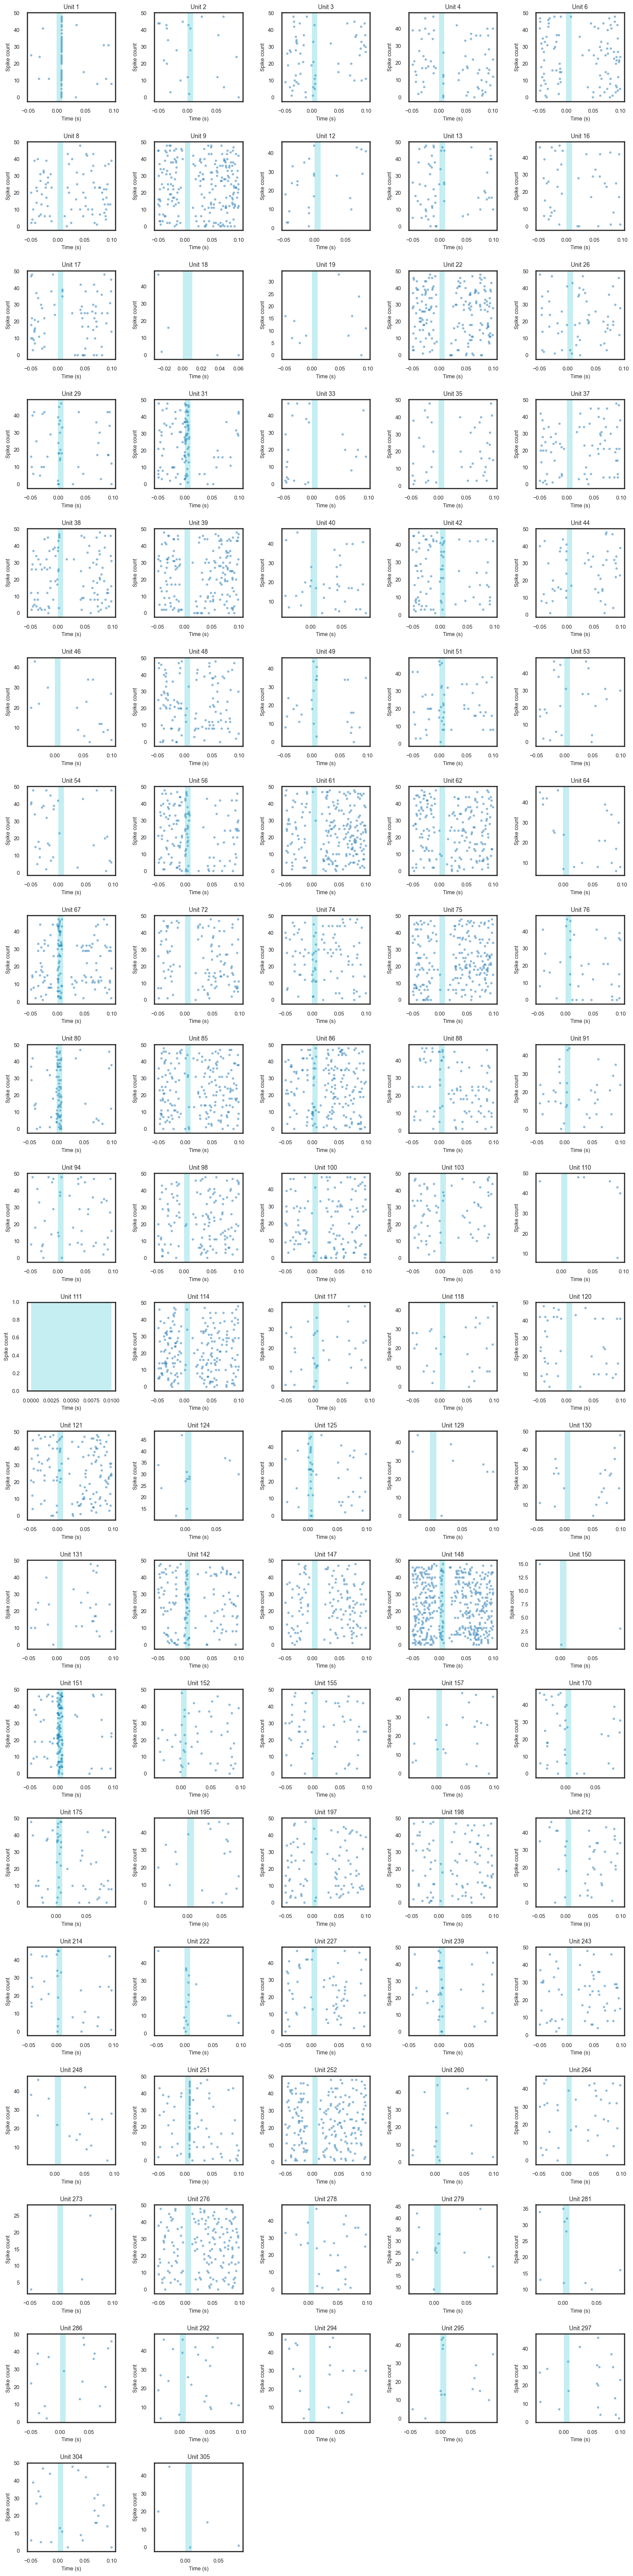

Saved PSTH plots for 97 units aligned to blue opto


In [12]:
event = blueLaser_onsets
event_label = 'blue opto'
bin_size_ms = 5             # in ms
time_range = (-0.05,0.1)    # in sec
event_color = 'tab:cyan'
event_duration = 0.01        # in sec

ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
                    good_units=good_units, good_unit_ids=good_unit_ids,
                    same_system=False, params=params, bin_size_ms=bin_size_ms,
                    event_color=event_color, event_duration=event_duration, event_label=event_label,
                    save_figure=True, save_folder=save_folder)

### Plot PSTH of red opto

Aligning spikes to onsets...
Finished: aligned 107 events
Shape: (97, 107, 500) (units, events, bins)


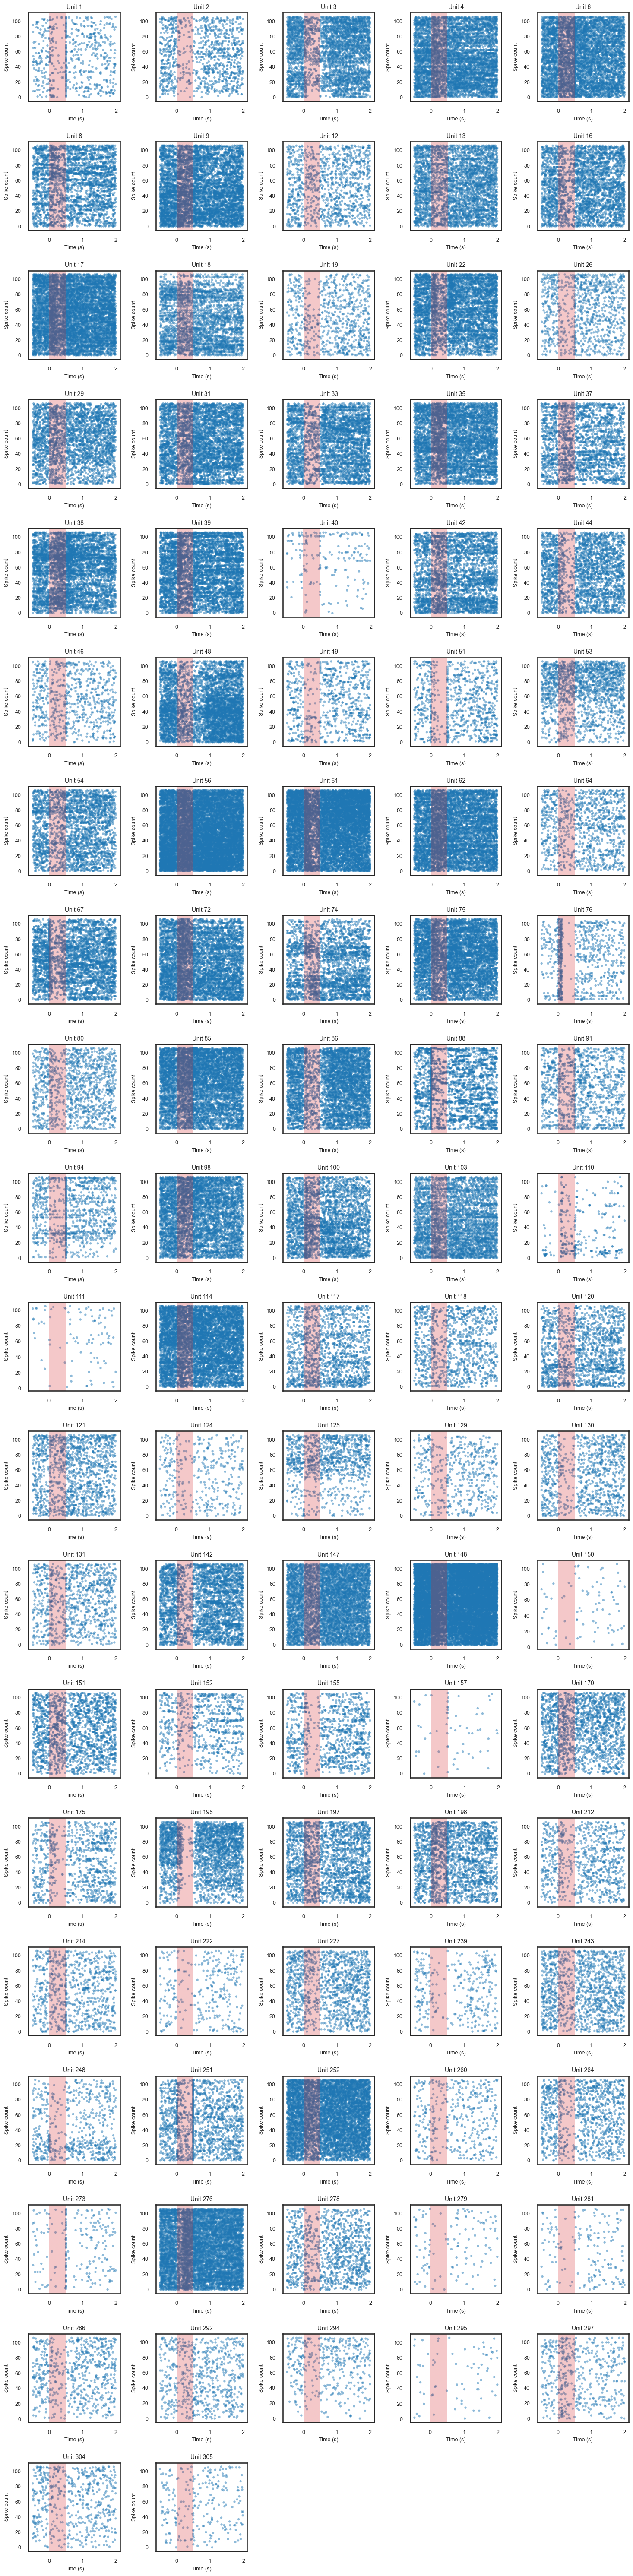

Saved PSTH plots for 97 units aligned to red opto


In [13]:
# Plot PSTH aligned to red stim
event = redLaser_onsets
event_label = 'red opto'
bin_size_ms = 5             # in ms
time_range = (-0.5,2)       # in sec
event_color = 'tab:red'
event_duration = 0.5        # in sec

ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
                    good_units=good_units, good_unit_ids=good_unit_ids,
                    same_system=False, params=params, bin_size_ms=bin_size_ms,
                    event_color=event_color, event_duration=event_duration, event_label=event_label,
                    save_figure=True, save_folder=save_folder)

### Plot PSTH of water events

In [ ]:
# Plot PSTH aligned to water
event = water_lick_onsets
event_label = 'water'
bin_size_ms = 5             # in ms
time_range = (-0.5,2)       # in sec
event_color = 'tab:cyan'
event_duration = 0.2        # in sec

ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
                    good_units=good_units, good_unit_ids=good_unit_ids,
                    same_system=False, params=params, bin_size_ms=bin_size_ms,
                    event_color=event_color, event_duration=event_duration, event_label=event_label,
                    save_figure=True, save_folder=save_folder)

Aligning spikes to onsets...
Finished: aligned 107 events
Shape: (97, 107, 500) (units, events, bins)


### Plot PSTH of airpuff

In [ ]:
# Plot PSTH aligned to airpuff
event = airpuff_onsets
event_label = 'water'
bin_size_ms = 5             # in ms
time_range = (-0.5,2)       # in sec
event_color = 'tab:gray'
event_duration = 0.2        # in sec

ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
                    good_units=good_units, good_unit_ids=good_unit_ids,
                    same_system=False, params=params, bin_size_ms=bin_size_ms,
                    event_color=event_color, event_duration=event_duration, event_label=event_label,
                    save_figure=True, save_folder=save_folder)

Aligning spikes to onsets...
Finished: aligned 0 events
Shape: (119, 0, 500) (units, events, bins)
No units or events to plot


## Load LFP of the session

In [ ]:
from hdmf_zarr.nwb import NWBZarrIO

# If your store does not have consolidated metadata, use mode="r-"
# (read-only without requiring consolidated metadata)
with NWBZarrIO(nwb_path, mode="r") as io:
    nwbfile = io.read()

    # LFP is typically stored under processing/ecephys/LFP in these files
    ecephys = nwbfile.processing["ecephys"]
    lfp_iface = ecephys["LFP"]

    print("Available LFP ElectricalSeries:", list(lfp_iface.electrical_series.keys()))
    es_name = list(lfp_iface.electrical_series.keys())[0]  # choose the right one
    lfp_es = lfp_iface.electrical_series[es_name]

    lfp = lfp_es.data          # lazy; slicing reads only the requested chunk
    lfp_timestamp = lfp_es.timestamps      # usually present; also lazy
    lfp_timestamp = np.asarray(lfp_timestamp, float)

# Map LFP timestamp to timeNI
half_sample_shift = float(lfp_timestamp[0])
timeLFP = (lfp_timestamp - half_sample_shift) + float(params['sync']['timeImec'][0])
# Add timeLFP to params['sync']
params['sync']['timeLFP'] = timeLFP
params['sync']['lfpFs'] = int(lfp_timestamp.shape[0] / (timeLFP[-1] - timeLFP[0]))

print("LFP shape:", lfp.shape)
print("LFP timestamp shape:", timeLFP.shape)
print("LFP sampling rate:", params['sync']['lfpFs'])

Available LFP ElectricalSeries: ['ElectricalSeriesNeuropixels 2.0 - Four Shank-LFP']
LFP shape: (3276250, 96)
LFP timestamp shape: (3276250,)
LFP sampling rate: 1250


### Align LFP to red stim

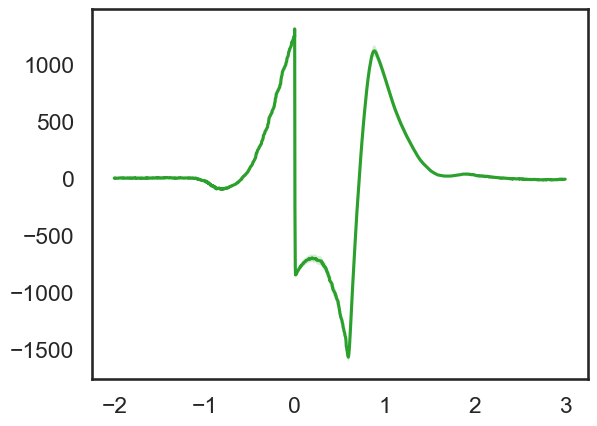

In [ ]:
chan = 0
traces, ts = ndap.get_traces(lfp[:,chan], redLaser_onsets, time_range=(-2, 3),
                            same_system=False, params=params, signal_system="lfp")

ndap.plot_sem(traces, ts, plot_individual=False, color='tab:green')

In [ ]:
cluster_info_enhanced.head()

,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,d_prime,drift_mad,drift_ptp,drift_std,firing_range,firing_rate,...,velocity_below,peak_channel,segment_name,n_samples,trough_to_peak_ms,global_unit_ids,labels,default_qc,manual_quality,quality
0,0.010777,0.301269,1.125538,-63.574220,2.997546,NaN,NaN,NaN,1.60,0.651072,...,NaN,89,block0_imec0.ap_recording1,384,0.433333,1,mua,False,True,False
1,0.000429,0.357062,0.997042,-54.492188,3.014356,1.516902,6.716370,0.924027,2.80,2.422723,...,NaN,91,block0_imec0.ap_recording1,384,0.433333,2,mua,True,True,True
2,0.000222,0.312364,0.111799,-57.519530,2.264735,0.343113,2.189102,0.515268,6.60,5.599048,...,NaN,90,block0_imec0.ap_recording1,384,0.433333,3,mua,True,True,True
3,0.000220,0.267902,0.107125,-72.656250,4.226645,1.353287,5.077652,1.433104,13.33,14.570513,...,NaN,90,block0_imec0.ap_recording1,384,0.400000,4,sua,True,True,True
4,0.002668,0.207780,0.095672,-118.066410,3.497605,2.166488,6.505859,2.141684,17.33,18.653811,...,NaN,90,block0_imec0.ap_recording1,384,0.400000,5,sua,True,True,True


### Get the waveform for these units

- Get the waveform from sorting summary link: 
https://figurl.org/f?v=npm://@fi-sci/figurl-sortingview@12/dist&d=sha1://cc77d5a8dbab94da537aff8b268c422131b7cea1&label=ecephys_session%20-%20block0_imec0.ap_recording1%20-%20kilosort4%20-%20Sorting%20Summary 